In [ ]:
import kagglehub
abhi8923shriv_sentiment_analysis_dataset_path = kagglehub.dataset_download('abhi8923shriv/sentiment-analysis-dataset')
another_data=kagglehub.dataset_download("yuvrayui/sentiment-analysis-with-text")
print('Data source import complete.')


Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Using Colab cache for faster access to the 'sentiment-analysis-with-text' dataset.
Data source import complete.


# <p style="font-family:Bradley Hand ITC;font-size:150%;text-align:center;color:#EEBB6D;">Import Libraries & DataSet</p>

In [ ]:

import os
import re
import warnings
from string import punctuation

# Suppress warning messages
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import LancasterStemmer
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/sentiment-analysis-with-text/The best sentiment analysis -all time.csv
/kaggle/input/sentiment-analysis-dataset/training.1600000.processed.noemoticon.csv
/kaggle/input/sentiment-analysis-dataset/train.csv
/kaggle/input/sentiment-analysis-dataset/testdata.manual.2009.06.14.csv
/kaggle/input/sentiment-analysis-dataset/test.csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# <p style="font-family:Bradley Hand ITC;font-size:150%;text-align:center;color:#EEBB6D;">Load Train & Test DATASET </p>

In [ ]:
import os

train_data = pd.read_csv(os.path.join(abhi8923shriv_sentiment_analysis_dataset_path, 'train.csv'),encoding='latin1');
train_data_1= pd.read_csv(os.path.join(another_data, 'The best sentiment analysis -all time.csv'),encoding='latin1');

# <p style="font-family:Bradley Hand ITC;font-size:150%;text-align:center;color:#EEBB6D;">DISPLAY DATASET </p>

In [ ]:
#df=train_data
df=pd.concat([train_data,train_data_1],axis=0)
df.head(3)

,textID,text,selected_text,sentiment,Time of Tweet,Age of User,Country,Population -2020,Land Area (Km²),Density (P/Km²)
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,morning,0-20,Afghanistan,38928346.0,652860.0,60.0
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,noon,21-30,Albania,2877797.0,27400.0,105.0
2,088c60f138,my boss is bullying me...,bullying me,negative,night,31-45,Algeria,43851044.0,2381740.0,18.0


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,14452
positive,11916
negative,11115


# <p style="font-family:Bradley Hand ITC;font-size:150%;text-align:center;color:#EEBB6D;">CHECKING DTYPES </p>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37483 entries, 0 to 10001
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   textID            27481 non-null  object 
 1   text              37482 non-null  object 
 2   selected_text     27480 non-null  object 
 3   sentiment         37483 non-null  object 
 4   Time of Tweet     27481 non-null  object 
 5   Age of User       27481 non-null  object 
 6   Country           27481 non-null  object 
 7   Population -2020  27481 non-null  float64
 8   Land Area (Km²)   27481 non-null  float64
 9   Density (P/Km²)   27481 non-null  float64
dtypes: float64(3), object(7)
memory usage: 3.1+ MB


Drop unwanted columns

In [ ]:
df = df.drop(columns=[
    'textID',
    'Time of Tweet',
    'Age of User',
    'Country',
    'Population -2020',
    'Land Area (Km²)',
    'Density (P/Km²)','selected_text'
])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(37482, 2)

In [ ]:
df.head(5)

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [ ]:
df.isnull().sum()

,0
text,0
sentiment,0


PREPROCESSING

In [ ]:
# Initialize objects
stop_words = set(stopwords.words('english'))
stemmer = LancasterStemmer()

def preprocess_text(text):
    # Convert to string
    text = str(text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove words containing numbers
    text = re.sub(r'\w*\d\w*', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Join tokens back into a sentence
    return " ".join(tokens)

# Apply preprocessing
df['processed_text'] = df['text'].apply(preprocess_text)

# View results
df=df[23500:]

In [ ]:
X = df['processed_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()

XV_train = vectorizer.fit_transform(X_train)
XV_test = vectorizer.transform(X_test)


In [ ]:
# Initialize the Random Forest model
rfc = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train the model
rfc.fit(XV_train, y_train)
# Predict on the test data
y_pred = rfc.predict(XV_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.95      0.85      0.90       893
     neutral       0.83      0.93      0.88      1013
    positive       0.93      0.90      0.92       891

    accuracy                           0.90      2797
   macro avg       0.91      0.90      0.90      2797
weighted avg       0.90      0.90      0.90      2797



In [ ]:
svm_model = SVC(
    kernel='linear',
    random_state=42
)
svm_model.fit(XV_train, y_train)
y_pred = svm_model.predict(XV_test)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.92      0.86      0.89       893
     neutral       0.84      0.91      0.87      1013
    positive       0.93      0.90      0.92       891

    accuracy                           0.89      2797
   macro avg       0.90      0.89      0.89      2797
weighted avg       0.90      0.89      0.89      2797



In [ ]:
# Encode labels
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=60,
    learning_rate=0.1,
    max_depth=9,
    random_state=42,
    eval_metric='mlogloss'
)

# Train the model
xgb.fit(XV_train, y_train_encoded)

# Predict on the test data
y_pred = xgb.predict(XV_test)

# Evaluate the model
print(classification_report(y_test_encoded, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.81      0.88       893
           1       0.79      0.96      0.86      1013
           2       0.94      0.88      0.91       891

    accuracy                           0.88      2797
   macro avg       0.90      0.88      0.89      2797
weighted avg       0.90      0.88      0.88      2797



In [ ]:
import joblib

joblib.dump(svm_model, 'svc_model.pkl')
joblib.dump(rfc, 'random_forest_model.pkl')
joblib.dump(xgb, 'xgboost_model.pkl')

joblib.dump(le, 'label_encoder.pkl')
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("All models saved successfully!")

All models saved successfully!


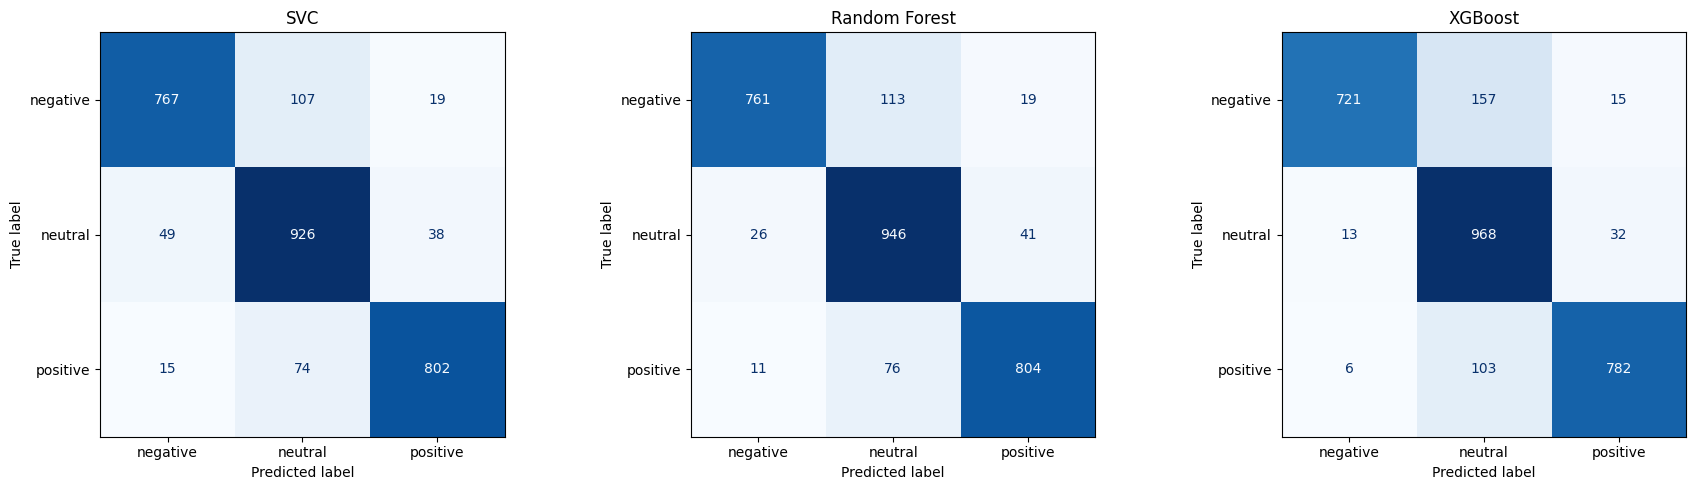

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
svc_pred = svm_model.predict(XV_test)
rf_pred = rfc.predict(XV_test)

# XGBoost predictions (convert back to original labels)
xgb_pred = xgb.predict(XV_test)
xgb_pred = le.inverse_transform(xgb_pred)

# Create confusion matrices
cm_svc = confusion_matrix(y_test, svc_pred)
cm_rf = confusion_matrix(y_test, rf_pred)
cm_xgb = confusion_matrix(y_test, xgb_pred)

# Create side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# SVC
ConfusionMatrixDisplay(
    confusion_matrix=cm_svc,
    display_labels=svm_model.classes_
).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("SVC")

# Random Forest
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rfc.classes_
).plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title("Random Forest")

# XGBoost
ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=le.classes_
).plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title("XGBoost")

plt.tight_layout()
plt.show()

In [ ]:
import joblib

svc = joblib.load("svc_model.pkl")
rfc = joblib.load("random_forest_model.pkl")
xgb = joblib.load("xgboost_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")
le = joblib.load("label_encoder.pkl")

text = "what the fuck"

processed = preprocess_text(text)
text_vector = vectorizer.transform([processed])
svc_prediction = svc.predict(text_vector)[0]

rf_prediction = rfc.predict(text_vector)[0]

xgb_prediction = xgb.predict(text_vector)
xgb_prediction = le.inverse_transform(xgb_prediction)[0]
print("Input Text :", text)
print("SVC Prediction           :", svc_prediction)
print("Random Forest Prediction :", rf_prediction)
print("XGBoost Prediction       :", xgb_prediction)

Input Text : what the fuck
SVC Prediction           : neutral
Random Forest Prediction : neutral
XGBoost Prediction       : neutral


Data analysis and Data results

In [ ]:
from collections import Counter
from wordcloud import WordCloud

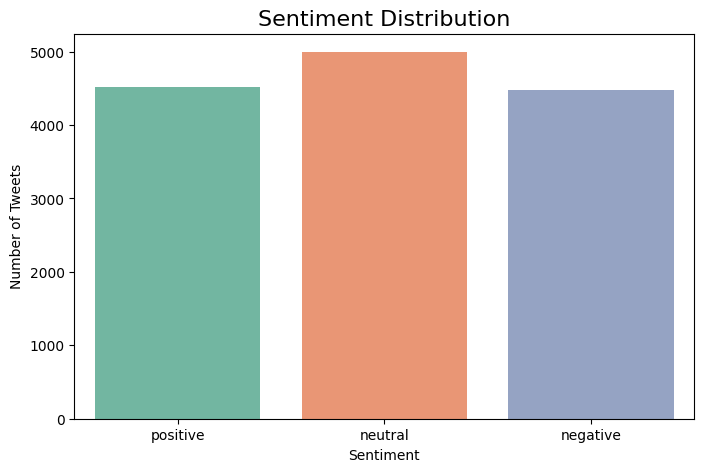

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='sentiment', data=df, palette='Set2')

plt.title("Sentiment Distribution", fontsize=16)
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.xticks(rotation=0)
plt.show()

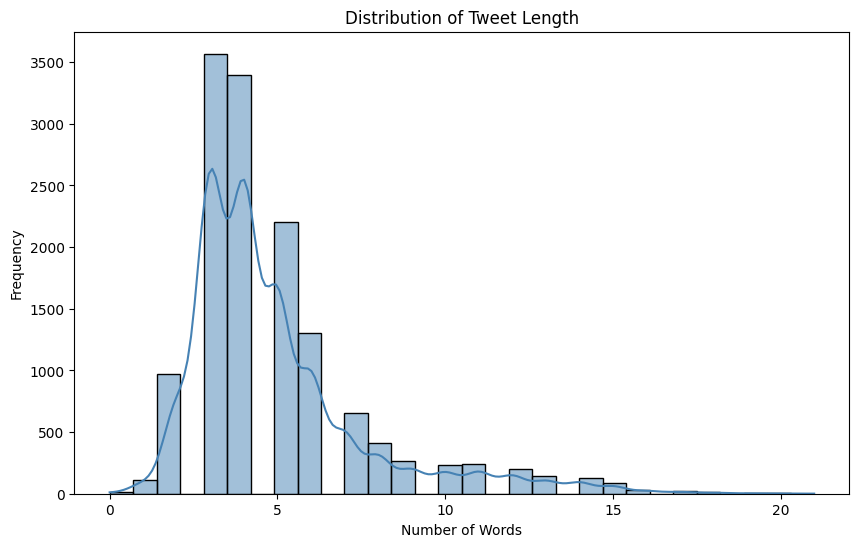

In [ ]:
df['tweet_length'] = df['processed_text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,6))

sns.histplot(df['tweet_length'],
             bins=30,
             kde=True,
             color='steelblue')

plt.title("Distribution of Tweet Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

In [ ]:
all_words = ' '.join(df['processed_text'])

word_counts = Counter(all_words.split())

common_words = word_counts.most_common(20)

words = [word for word, count in common_words]
counts = [count for word, count in common_words]

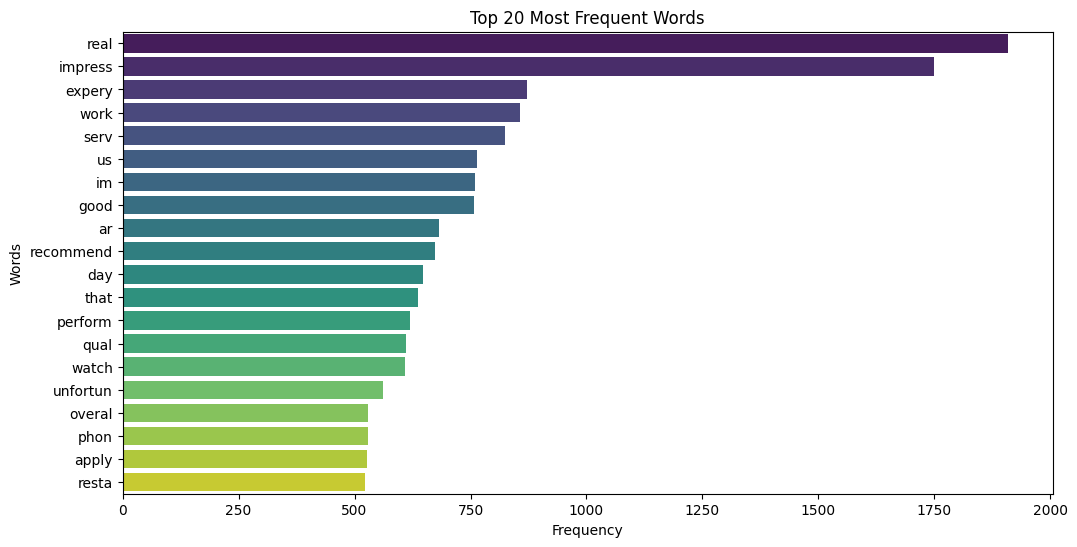

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(x=counts,
            y=words,
            palette='viridis')

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

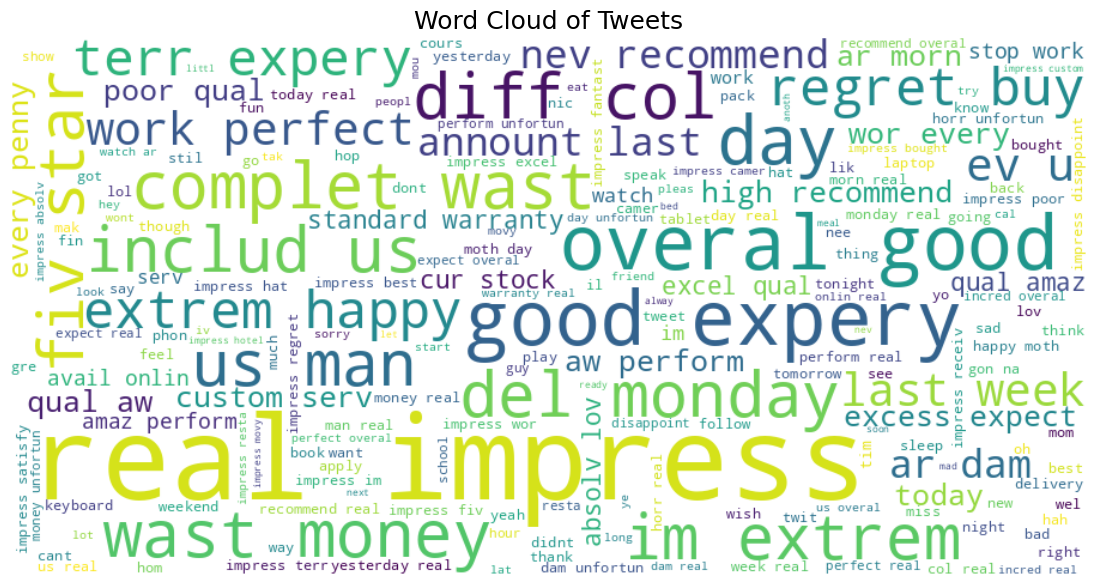

In [ ]:
text = " ".join(df['processed_text'])

wordcloud = WordCloud(width=900,
                      height=450,
                      background_color='white',
                      colormap='viridis').generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud, interpolation='bilinear')

plt.axis("off")

plt.title("Word Cloud of Tweets", fontsize=18)

plt.show()

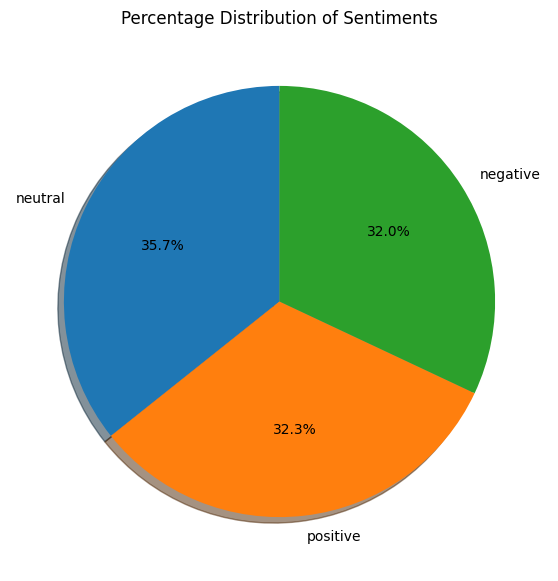

In [ ]:
plt.figure(figsize=(7,7))

df['sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    shadow=True
)

plt.ylabel("")
plt.title("Percentage Distribution of Sentiments")

plt.show()

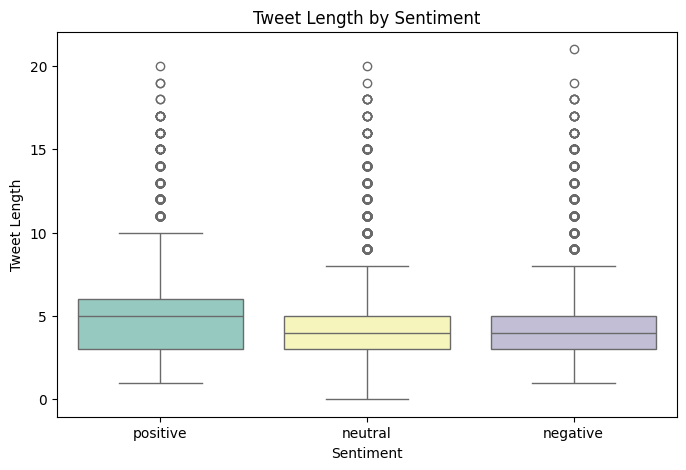

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='sentiment',
    y='tweet_length',
    data=df,
    palette='Set3'
)

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")

plt.show()